In [20]:
import sys
import os

path_to_scripts = os.path.join('..', '..', 'python_scripts')
sys.path.append(path_to_scripts)

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_error, max_error

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

from data_to_bigquery import load_from_bigquery
from feature_engineering import drop_lag_nulls, validate_features, engineer_features
from baseline_model import baseline_model_xgb, xgb_train_preproc, evaluate_trained_model, pred_preproc_xgb, xgb_prediction


%matplotlib inline

# Function checking 

In [ ]:
# raw table
df_raw = load_from_bigquery('gridzero-489711', 'merged_set', 'test_merge_2017_onward_raw')
# display(df_raw.head())
# df_raw.columns

In [ ]:
# train preproc function
df_pre = xgb_train_preproc(df_raw, add_year_lag=True)
# success working!

In [ ]:
# checking train_preproc
print(df_raw.shape)
print(df_pre.shape)
print(df_pre.columns.tolist())
print(df_pre.isna().sum().sum())
# success working!

In [ ]:
# checking model function
model, X_train, X_test, y_train, y_test = baseline_model_xgb()
# success working!

In [ ]:
# evaluate trained model
metrics = evaluate_trained_model(model, X_test, y_test)
print(metrics)

In [ ]:
# pred_preproc using X_test as df_new to check fucntion is working
#takes model ouput X_train
feature_cols = X_train.columns.tolist()

X_new = pred_preproc_xgb(df_new=X_test.copy(),
                     feature_cols=feature_cols
                     )

print(X_new.shape)
print(X_new.columns.tolist() == feature_cols)
print(X_new.isna().sum().sum())

In [ ]:
# checking prediction fucntion
prediction = xgb_prediction(
            model=model,
            df_new=X_test.copy(),
            feature_cols=feature_cols
            )

print(type(prediction))
print(len(prediction))
print(prediction[:5])

## Testing that saucey tables and raw_data tables parse 

In [ ]:
# Joe's saucey table
df_saucey = load_from_bigquery('gridzero-489711', 'merged_set', 'test_merge_with_the_sauce')

print(df.shape)
print(df.dtypes)
print(df.isna().sum().sort_values(ascending=False).head(20))

In [ ]:
df = baseline_preproc(df, target_col='carbon_intensity_gCO2_kWh')

lag_cols = [col for col in ['lag_48', 'lag_336', 'lag_17520'] if col in df.columns]
if lag_cols:
    df = df.dropna(subset=lag_cols)

X = df.drop(columns=['carbon_intensity_gCO2_kWh', 'datetime'], errors='ignore')

print(X.shape)
print(X.dtypes)
print(X.isna().sum().sort_values(ascending=False).head(20))
print(X.select_dtypes(exclude=['number', 'bool']).columns.tolist())

In [ ]:
df_saucey = load_from_bigquery('gridzero-489711', 'merged_set', 'test_merge_with_the_sauce')
display(df_saucey.head())

print(df_saucey.columns.tolist())
print(df_saucey.dtypes)


In [ ]:
# BBoujie af LLM CHECK to help debugging to make sure all tables parse
# tables = ['test_merge_2017_onward_raw', 'test_merge_with_the_sauce']

# for table in tables:
#     print(f"\n--- TESTING PREPROC: {table} ---")

#     df = load_from_bigquery(
#         PROJECT='gridzero-489711',
#         DATASET='merged_set',
#         TABLE=table
#     )

#     df_pre = baseline_preproc(df)

#     print("raw shape:", df.shape)
#     print("preproc shape:", df_pre.shape)
#     print("columns after preproc:", df_pre.columns.tolist())

#     target_candidates = [c for c in df_pre.columns if 'carbon_intensity' in c]
#     print("target candidates:", target_candidates)

#     if target_candidates:
#         target_col = target_candidates[0]
#         print("target NA count:", df_pre[target_col].isna().sum())

#     lag_cols = [c for c in ['lag_48', 'lag_336', 'lag_17520'] if c in df_pre.columns]
#     print("lag cols present:", lag_cols)

#     if lag_cols:
#         print("lag NA counts:")
#         print(df_pre[lag_cols].isna().sum())

#     print("total NA count in preproc df:", df_pre.isna().sum().sum())

In [ ]:
# BBoujie af LLM CHECK to help debugging to make sure all tables parse
# for table in tables:
#     print(f"\n--- TESTING X / y: {table} ---")

#     df = load_from_bigquery(
#         PROJECT='gridzero-489711',
#         DATASET='merged_set',
#         TABLE=table
#     )

#     df_pre = baseline_preproc(df)

#     target_col = [c for c in df_pre.columns if 'carbon_intensity' in c][0]

#     X = df_pre.drop(columns=[target_col, 'datetime'], errors='ignore').copy()
#     X = X.select_dtypes(include='number').astype(float)

#     y = df_pre[target_col].astype(float)

#     print("X shape:", X.shape)
#     print("y shape:", y.shape)
#     print("non-numeric cols left:", X.select_dtypes(exclude='number').columns.tolist())
#     print("X total NA count:", X.isna().sum().sum())
#     print("y total NA count:", y.isna().sum())

In [ ]:
# BBoujie af LLM CHECK to help debugging to make sure all tables parse
# for table in tables:
#     print(f"\n--- FITTING MODEL: {table} ---")
#     model = baseline_model_xgb(TABLE=table)
#     print(model)

In [ ]:
# check carb intensity from engingeer features function
# df = engineer_features(df, target_col='carbon_intensity_gCO2_kWh')
# df.head()

In [ ]:
# debugging python imports
# import baseline_model
# print(baseline_model.__file__)
# print('baseline_preproc' in dir(baseline_model))
# print(dir(baseline_model))

## Initial laoding and fucntion checking

In [50]:
model = baseline_model_xgb('gridzero-489711', 'merged_set', 'test_merge_2017_onward_raw')
model

/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Loaded 148,991 rows and 26 columns from gridzero-489711.merged_set.test_merge_2017_onward_raw


(XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...),
         temperature_2m_c  wind_speed_100m_ms  wind_gusts_10m_ms  \
 27839                4.8                25.7               21.2   
 141340              14.1                48.9               81.4   
 5474                 6.5         

In [5]:
df = load_from_bigquery('gridzero-489711', 'merged_set', 'feature_engineered_dataset_2025')

/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Loaded 17,092 rows and 29 columns from gridzero-489711.merged_set.feature_engineered_dataset_2025


In [ ]:
df.head(1)
df.dtypes

In [ ]:
print(f'Shape: {df.shape}')
print(f'Nulls:\n{df.isnull().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')

# Baseline model

In [7]:
df = load_from_bigquery('gridzero-489711', 'merged_set', 'feature_engineered_dataset_2025')

/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Loaded 17,092 rows and 29 columns from gridzero-489711.merged_set.feature_engineered_dataset_2025


In [8]:
df.rename(columns={'time': 'datetime'})
df = df.rename(columns={'time': 'datetime'})

In [9]:
display(df.head(5))

display(engineer_features(df, target_col='carbon_intensity'))

,datetime,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,snowfall_cm,...,Wind Offshore,Wind Onshore,TotalOutput-MW,carbon_intensity,lag_48,lag_336,hour,day_of_week,month,is_weekend
0,2025-01-08 00:00:00+00:00,0.4,19.9,20.9,0,0.0,0.0,0.0,1003.6,0.0,...,10038.334,5580.935,28845.269,86,69,55,0,2,1,0
1,2025-01-08 00:30:00+00:00,0.4,19.9,20.9,0,0.0,0.0,0.0,1003.6,0.0,...,9821.886,5547.003,28739.889,84,68,54,0,2,1,0
2,2025-01-08 01:00:00+00:00,0.6,18.9,18.7,13,0.0,0.0,0.0,1003.9,0.0,...,9673.525,5395.306,28531.831,85,65,53,1,2,1,0
3,2025-01-08 01:30:00+00:00,0.6,18.9,18.7,13,0.0,0.0,0.0,1003.9,0.0,...,9508.819,5288.912,27985.731,88,66,53,1,2,1,0
4,2025-01-08 02:00:00+00:00,0.2,19.2,18.4,97,0.0,0.0,0.0,1004.4,0.0,...,9436.926,4880.031,27592.957,90,63,47,2,2,1,0


,datetime,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,snowfall_cm,...,Wind Offshore,Wind Onshore,TotalOutput-MW,carbon_intensity,lag_48,lag_336,hour,day_of_week,month,is_weekend
0,2025-01-08 00:00:00+00:00,0.4,19.9,20.9,0,0.0,0.0,0.0,1003.6,0.0,...,10038.334,5580.935,28845.269,86,<NA>,<NA>,0,2,1,0
1,2025-01-08 00:30:00+00:00,0.4,19.9,20.9,0,0.0,0.0,0.0,1003.6,0.0,...,9821.886,5547.003,28739.889,84,<NA>,<NA>,0,2,1,0
2,2025-01-08 01:00:00+00:00,0.6,18.9,18.7,13,0.0,0.0,0.0,1003.9,0.0,...,9673.525,5395.306,28531.831,85,<NA>,<NA>,1,2,1,0
3,2025-01-08 01:30:00+00:00,0.6,18.9,18.7,13,0.0,0.0,0.0,1003.9,0.0,...,9508.819,5288.912,27985.731,88,<NA>,<NA>,1,2,1,0
4,2025-01-08 02:00:00+00:00,0.2,19.2,18.4,97,0.0,0.0,0.0,1004.4,0.0,...,9436.926,4880.031,27592.957,90,<NA>,<NA>,2,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17087,2025-12-30 21:30:00+00:00,2.2,18.6,17.3,13,0.0,0.0,0.0,1034.4,0.0,...,6372.583,2235.443,32410.026,174,139,77,21,1,12,0
17088,2025-12-30 22:00:00+00:00,1.9,17.4,16.2,3,0.0,0.0,0.0,1034.1,0.0,...,6219.397,2341.534,30311.931,159,127,74,22,1,12,0
17089,2025-12-30 22:30:00+00:00,1.9,17.4,16.2,3,0.0,0.0,0.0,1034.1,0.0,...,6191.124,2457.936,28670.060,138,106,71,22,1,12,0
17090,2025-12-30 23:00:00+00:00,1.6,17.1,14.4,20,0.0,0.0,0.0,1034.1,0.0,...,6045.085,2580.600,25820.685,122,96,71,23,1,12,0


In [10]:
df = engineer_features(df)
validate_features(df)
df = drop_lag_nulls(df)
df

Shape: (17092, 29)

Columns:
['datetime', 'temperature_2m_c', 'wind_speed_100m_ms', 'wind_gusts_10m_ms', 'cloud_cover_pct', 'shortwave_radiation_wm2', 'direct_radiation_wm2', 'diffuse_radiation_wm2', 'pressure_msl_hpa', 'snowfall_cm', 'Biomass', 'Fossil Gas', 'Fossil Hard coal', 'Fossil Oil', 'Hydro Pumped Storage', 'Hydro Run-of-river and poundage', 'Nuclear', 'Other', 'Solar', 'Wind Offshore', 'Wind Onshore', 'TotalOutput-MW', 'carbon_intensity', 'lag_48', 'lag_336', 'hour', 'day_of_week', 'month', 'is_weekend']

Missing values:
datetime                             0
temperature_2m_c                     0
wind_speed_100m_ms                   0
wind_gusts_10m_ms                    0
cloud_cover_pct                      0
shortwave_radiation_wm2              0
direct_radiation_wm2                 0
diffuse_radiation_wm2                0
pressure_msl_hpa                     0
snowfall_cm                          0
Biomass                              0
Fossil Gas                        

,datetime,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,snowfall_cm,...,Wind Offshore,Wind Onshore,TotalOutput-MW,carbon_intensity,lag_48,lag_336,hour,day_of_week,month,is_weekend
0,2025-01-15 00:00:00+00:00,7.7,16.7,14.4,100,0.0,0.0,0.0,1034.8,0.0,...,3186.058,5041.468,30620.526,197,116,86,0,2,1,0
1,2025-01-15 00:30:00+00:00,7.7,16.7,14.4,100,0.0,0.0,0.0,1034.8,0.0,...,3119.306,5203.536,30587.842,198,120,84,0,2,1,0
2,2025-01-15 01:00:00+00:00,8.6,16.1,15.1,100,0.0,0.0,0.0,1034.2,0.0,...,2937.781,5155.350,30551.131,198,116,85,1,2,1,0
3,2025-01-15 01:30:00+00:00,8.6,16.1,15.1,100,0.0,0.0,0.0,1034.2,0.0,...,2795.310,5104.542,30298.852,197,117,88,1,2,1,0
4,2025-01-15 02:00:00+00:00,8.5,14.9,13.3,100,0.0,0.0,0.0,1033.9,0.0,...,2559.351,5071.669,29789.020,194,115,90,2,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16751,2025-12-30 21:30:00+00:00,2.2,18.6,17.3,13,0.0,0.0,0.0,1034.4,0.0,...,6372.583,2235.443,32410.026,174,139,77,21,1,12,0
16752,2025-12-30 22:00:00+00:00,1.9,17.4,16.2,3,0.0,0.0,0.0,1034.1,0.0,...,6219.397,2341.534,30311.931,159,127,74,22,1,12,0
16753,2025-12-30 22:30:00+00:00,1.9,17.4,16.2,3,0.0,0.0,0.0,1034.1,0.0,...,6191.124,2457.936,28670.060,138,106,71,22,1,12,0
16754,2025-12-30 23:00:00+00:00,1.6,17.1,14.4,20,0.0,0.0,0.0,1034.1,0.0,...,6045.085,2580.600,25820.685,122,96,71,23,1,12,0


In [11]:
# data features and target
# note dropped target AND datime
# note renamed time to datetime to make sure engineerign features work
X = df.drop(columns=['carbon_intensity', 'datetime'])
y = df['carbon_intensity']

print(X.dtypes)

temperature_2m_c                   float64
wind_speed_100m_ms                 float64
wind_gusts_10m_ms                  float64
cloud_cover_pct                      Int64
shortwave_radiation_wm2            float64
direct_radiation_wm2               float64
diffuse_radiation_wm2              float64
pressure_msl_hpa                   float64
snowfall_cm                        float64
Biomass                            float64
Fossil Gas                         float64
Fossil Hard coal                   float64
Fossil Oil                         float64
Hydro Pumped Storage               float64
Hydro Run-of-river and poundage    float64
Nuclear                            float64
Other                              float64
Solar                              float64
Wind Offshore                      float64
Wind Onshore                       float64
TotalOutput-MW                     float64
lag_48                               Int64
lag_336                              Int64
hour       

In [12]:
y


0        197
1        198
2        198
3        197
4        194
        ... 
16751    174
16752    159
16753    138
16754    122
16755    121
Name: carbon_intensity, Length: 16756, dtype: Int64

In [13]:
# test train split for 2025
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((11729, 27), (5027, 27), (11729,), (5027,))

In [ ]:
# simple pipelines

# pipeline = make_pipeline(
#     XGBRegressor(
#         n_estimators=100,
#         learning_rate=0.1,
#         max_depth=6,
#     )
# )

# pipeline_xgbr1 = make_pipeline(
#     StandardScaler(),
#     XGBRegressor(
#         n_estimators=100,
#         learning_rate=0.1,
#         max_depth=6,
#         random_state=42
#     )
# )


In [ ]:
# pipeline.fit(X_train, y_train)
# y_pred = pipeline.predict(X_test)
# print(y)
# print(y_pred)

In [ ]:
# results = cross_validate(
#     pipeline,
#     X_train,
#     y_train,
#     cv=5,
#     scoring=['neg_mean_squared_error', 'neg_root_mean_squared_error', 'r2', 'neg_mean_absolute_error', 'neg_max_error']
# )

# results


In [ ]:
# test_results = {k: v for k, v in results.items() if k.startswith('test')}
# test_results = pd.DataFrame(test_results)

# display(test_results)

In [ ]:
# plt.figure(figsize=(10,4))
# plt.plot(y_test.values, label='true')
# plt.plot(y_pred, label='pred')
# plt.show()

In [ ]:
# DO NOT NEED bc we have enegineered features
# function to extract from datetime
# def extract_datetime_features(df):
#     df = df.copy()
#     dt = pd.to_datetime(df.iloc[:, 0])

#     return pd.DataFrame({
#         'hour': dt.dt.hour,
#         'day': dt.dt.day,
#         'month': dt.dt.month,
#         'dayofweek': dt.dt.dayofweek
#     }, index=df.index)

In [14]:
# model comparison
models = {
    'dummy': make_pipeline(
        DummyRegressor(strategy='mean')
    ),
    'linear_regression': make_pipeline(
        StandardScaler(),
        LinearRegression()
    ),
    'random_forest': make_pipeline(
        RandomForestRegressor(
            n_estimators=100,
            random_state=42
        )
    ),
    'xgboost_default': make_pipeline(
            XGBRegressor()
    ),

    'xgboost': make_pipeline(
        XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            objective='reg:squarederror'
        )
    ),
    'xgboost_scl': make_pipeline(
        StandardScaler(),
        XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42
        )
    ),
    'xgboost_opt1' : make_pipeline(
        XGBRegressor(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=5,
            #L1
            reg_alpha=0.1,
            #L2
            reg_lambda=0,
            # histo method (faster than default greedy algo)
            tree_method='hist',
            random_state=42
            )
    ),
    'xgboost_opt1_scl' : make_pipeline(
        StandardScaler(),
        XGBRegressor(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=5,
            reg_alpha=0.1,
            reg_lambda=1.0,
            tree_method='hist',
            random_state=42
            )

    ),

    'xgboost_opt2' : make_pipeline(
        XGBRegressor(
            n_estimators=2000,
            learning_rate=0.03,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            #histo
            tree_method='hist',
            random_state=42
            )
    )
}

In [15]:
# scoring
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2',
    'max_err':'neg_max_error'
}

In [16]:
# loop through models
# results
results = []

for model_name, pipeline in models.items():
    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        return_train_score=False
    )

    model_results = {
        'model': model_name,
        'model_fit_t': cv_results['fit_time'].mean(),
        'mae_mean': -cv_results['test_mae'].mean(),
        'rmse_mean': -cv_results['test_rmse'].mean(),
        'r2_mean': cv_results['test_r2'].mean(),
        'max_err_max': -cv_results['test_max_err'].max(),
    }

    results.append(model_results)

In [17]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('mae_mean')

display(results_df)

,model,model_fit_t,mae_mean,rmse_mean,r2_mean,max_err_max
8,xgboost_opt2,2.342905,4.523174,6.075748,0.988716,32.610413
3,xgboost_default,0.160176,5.345039,7.150570,0.984364,34.011749
4,xgboost,0.159929,5.384715,7.225126,0.984040,30.373779
5,xgboost_scl,0.204581,5.384715,7.225126,0.984040,30.373779
6,xgboost_opt1,0.601788,5.410307,7.185085,0.984219,31.096497
7,xgboost_opt1_scl,0.584942,5.440214,7.235652,0.983996,29.281143
2,random_forest,5.062392,5.807826,8.212739,0.979379,36.720000
1,linear_regression,0.008788,11.204435,15.010135,0.931147,78.121777
0,dummy,0.002209,48.556075,57.221031,-0.000242,144.126705


In [ ]:
# results:
# XGBOOST low MAE/RMSE/r2

In [ ]:
# simple model and predict in funcion
# pipeline = pipeline = make_pipeline(
#         StandardScaler(),
#         XGBRegressor()
# )

# pipeline.fit(X_train, y_train)

# y_pred = pipeline.predict(X_test)
# y_pred


In [ ]:
# testing fucntion codes

# backend
# model, feature_cols = baseline_model_xgb(TABLE='test_merge_with_the_sauce')

# simulating a front end table
# df_fr = load_from_bigquery('gridzero-489711','merged_set','test_merge_with_the_sauce')
# print(df_fr)

# # testing
# X_new = prepare_prediction_features(df_fr, feature_cols)

/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Loaded 1,535 rows and 27 columns from gridzero-489711.merged_set.test_merge_with_the_sauce


KeyError: "['carbon_intensity'] not found in axis"

In [ ]:
# Coarse grid search for hyperparams

param_grid = {
            'n_estimators': np.arange(500, 2000, 250),
            'max_depth': np.arange(3, 9, 3),
            'learning_rate': np.arange(0.01, 0.3, 0.01),
}

# param_grid = {
#     "n_estimators": [100, 300, 500],
#     "learning_rate": [0.01, 0.05, 0.1],
#     "max_depth": [3, 5, 7],
#     "min_child_weight": [1, 3, 5],
#     "subsample": [0.8, 1.0],
#     "colsample_bytree": [0.8, 1.0]
# }

In [ ]:
# grid search cross val
model = XGBRegressor()
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=scoring,
    refit = 'mae',
    cv=3,
    n_jobs=-1,
    verbose=2
)

# grid.fit(X_train, y_train)

In [41]:
# fit
grid.fit(X_train, y_train)

Fitting 3 folds for each of 348 candidates, totalling 1044 fits
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=500; total time=   3.4s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=500; total time=   3.4s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=500; total time=   3.7s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=750; total time=   4.2s
[CV] END .learning_rate=0.01, max_depth=3, n_estimators=1000; total time=   4.9s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=750; total time=   4.8s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=750; total time=   4.7s
[CV] END .learning_rate=0.01, max_depth=3, n_estimators=1000; total time=   5.4s
[CV] END .learning_rate=0.01, max_depth=3, n_estimators=1000; total time=   5.8s
[CV] END .learning_rate=0.01, max_depth=3, n_estimators=1250; total time=   7.0s
[CV] END .learning_rate=0.01, max_depth=3, n_estimators=1250; total time=   7.6s
[CV] END .learning_rate=0.01, max_depth=3, n_

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': array([0.01, ..., 0.28, 0.29]), 'max_depth': array([3, 6]), 'n_estimators': array([ 500, ..., 1500, 1750])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'mae': 'neg_mean_absolute_error', 'max_err': 'neg_max_error', 'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'mae'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbo

In [42]:
# # best model
best_model = grid.best_estimator_

In [43]:
# evaluation
results = pd.DataFrame(grid.cv_results_)

In [47]:
# predicting
y_pred = best_model.predict(X_test)

In [48]:
# best params and evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)
max_err = max_error(y_test, y_pred)

print("Best params:", grid.best_params_)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("Max Error:", max_err)


Best params: {'learning_rate': np.float64(0.05), 'max_depth': np.int64(6), 'n_estimators': np.int64(1750)}
MAE: 4.271311283111572
RMSE: 5.715928011996834
R2: 0.990020215511322
Max Error: 35.22937774658203


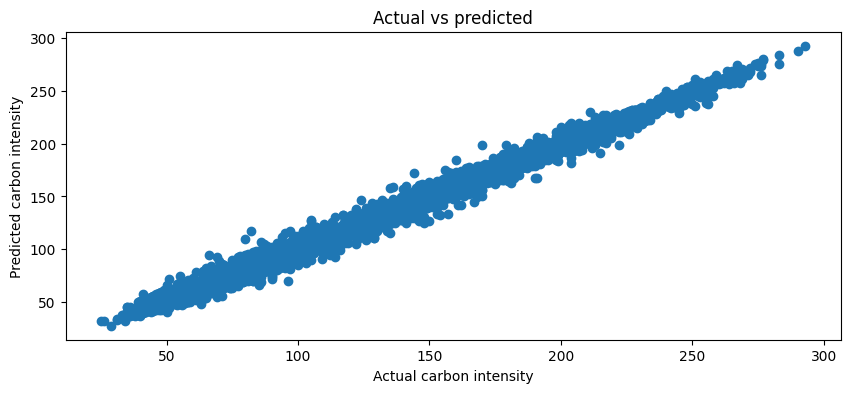

In [49]:
# visualisation

plt.figure(figsize=(10,4))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual carbon intensity')
plt.ylabel('Predicted carbon intensity')
plt.title('Actual vs predicted')
plt.plot(y_test.min(), y_test.max()),
plt.show()
